# 11. Empirical Bayesian Kriging 


**Dataset:** Jura geochemical survey (`data/jura_data.csv`, 359 samples) + prediction grid (`data/jura_grid.csv`)

**Target:** Cadmium (`Cd`, mg/kg), modelled on the log scale

**Library:** `pygstat.ebk` — Empirical Bayesian Kriging (Krivoruchko, 2012)


***
## Table of Contents

1. [Overview](#1-overview)
2. [How pygstat Implements EBK](#2-how-pygstat-implements-ebk)
3. [Python Setup](#3-python-setup)
4. [Load and Explore the Jura Cadmium Data](#4-load-and-explore-the-jura-cadmium-data)
5. [Stratified Split and Log Transform](#5-stratified-split-and-log-transform)
6. [Fit Empirical Bayesian Kriging](#6-fit-empirical-bayesian-kriging)
7. [The Semivariogram Ensemble](#7-the-semivariogram-ensemble)
8. [Validate EBK vs Ordinary Kriging](#8-validate-ebk-vs-ordinary-kriging)
9. [Predict Cd on the Jura Grid](#9-predict-cd-on-the-jura-grid)
10. [Probability Maps of Exceedance](#10-probability-maps-of-exceedance)
11. [Summary and Conclusions](#11-summary-and-conclusions)
12. [Resources](#12-resources)


***
## 1. Overview

### The problem it fixes

Ordinary/simple/universal kriging all follow the same two-step recipe:

1. Estimate the semivariogram parameters $\theta = (\mathrm{nugget},\,\mathrm{sill},\,\mathrm{range},\,\ldots)$ once from the data — e.g. by weighted least squares or REML — getting a single point estimate $\hat\theta$.
2. **Treat $\hat\theta$ as if it were the true, known $\theta$** and krige with it.

Step 2 is the weak link. $\hat\theta$ is itself an estimate with its own sampling error — especially with a modest sample size or a variogram whose range/nugget is hard to pin down — but classical kriging's reported prediction variance only accounts for spatial interpolation error *given* $\theta = \hat\theta$. It silently ignores the uncertainty in $\hat\theta$ itself, so kriging standard errors are systematically **too small**, and probability/quantile maps built from them are overconfident.

Empirical Bayesian Kriging (Krivoruchko, 2012) fixes this by not committing to a single $\hat\theta$ — it builds an empirical distribution over plausible semivariograms and averages predictions over that distribution.

### The Bayesian target

Conceptually, what you actually want is the posterior predictive distribution

$$
p\big(Z(x_0)\mid Z\big)
= \int p\big(Z(x_0)\mid Z,\theta\big)\, p(\theta\mid Z)\, d\theta,
$$

i.e. krige for every possible $\theta$, weighted by how consistent each $\theta$ is with the observed data. A fully Bayesian treatment (Handcock & Stein, 1993; Diggle & Ribeiro) specifies a prior $\pi(\theta)$ and samples $p(\theta\mid Z) \propto L(Z\mid\theta)\,\pi(\theta)$ via MCMC — expensive and requires prior elicitation.

EBK is **"empirical"** Bayesian because it sidesteps MCMC and a user-specified prior: it builds an approximation to $p(\theta\mid Z)$ directly from the data via a simulate-and-refit loop, the same spirit as empirical Bayes methods in statistics (estimate the "prior"/hyperparameter distribution from the data itself rather than specifying it a priori).

### The algorithm

For $k = 1, \ldots, K$ ($K \approx 100$ by default):

1. **Fit once.** Estimate a semivariogram $\hat\theta_0$ from the actual data $Z$ (REML is standard here, since it's less biased than method-of-moments for this purpose).
2. **Simulate.** Using $\hat\theta_0$ and the fitted mean, generate a synthetic Gaussian random field realization $Z^*_k$ at the *same* observation locations — this is what a dataset consistent with $\hat\theta_0$ would look like.
3. **Refit.** Re-estimate a new semivariogram $\theta_k$ from $Z^*_k$. Because $Z^*_k$ was simulated from $\hat\theta_0$, the scatter of $\theta_k$ across many $k$ approximates the *sampling distribution* of the semivariogram-fitting procedure around the truth — i.e. an empirical stand-in for $p(\theta\mid Z)$.
4. **Weight.** Krige $Z^*_k$ at its own input locations using $\theta_k$ and compare the kriged values to the actual simulated $Z^*_k$ — this consistency check yields a weight $w_k$ for how well that semivariogram explains its own data (poorly-behaved refits get downweighted).

This produces an ensemble $\{(\theta_1, w_1), \ldots, (\theta_K, w_K)\}$ — $K$ semivariograms with weights, standing in for the posterior over $\theta$.

**Prediction.** At a new location $x_0$, krige the *real* data $Z$ once per ensemble member:

$$
\hat Z_k(x_0),\; \sigma^2_k(x_0)
= \mathrm{SimpleKriging/OrdinaryKriging}(\theta_k).\mathrm{predict}(x_0)
\qquad k=1,\ldots,K.
$$

Then combine:

$$
\hat Z_{\mathrm{EBK}}(x_0) = \sum_k w_k\, \hat Z_k(x_0)
$$

$$
\begin{aligned}
\mathrm{Var}[Z(x_0)]
&= \sum_k w_k\, \sigma^2_k(x_0)
\quad\text{(average within-model kriging variance)} \\
&\quad + \sum_k w_k\, \big(\hat Z_k(x_0) - \hat Z_{\mathrm{EBK}}(x_0)\big)^2
\quad\text{(between-model variance, from $\theta$-uncertainty).}
\end{aligned}
$$

That variance decomposition is exactly the law of total variance / Rubin's multiple-imputation combining rule: *within-model* variance (ordinary kriging error, given $\theta$) plus *between-model* variance (disagreement across plausible $\theta$'s). Classical kriging only ever reports the first term — EBK's headline benefit is the second term, which is precisely the part that was previously ignored.

Because you actually have $K$ full predictive Gaussians $N\big(\hat Z_k(x_0),\,\sigma^2_k(x_0)\big)$ rather than one, you get a genuine **mixture-of-Gaussians predictive distribution** at every location, not just a mean and a variance — so exceedance-probability and quantile maps built from it are better calibrated than classical kriging's, especially in the small-sample/weak-range regime.

### Practical extras (as implemented in ArcGIS Geostatistical Analyst, the reference implementation)

- **Local, not global, semivariograms.** The study area is split into many overlapping subsets (a moving-window scheme); the whole simulate-refit-weight procedure above runs *per subset*, so the semivariogram can vary smoothly across space — a lightweight way of handling mild non-stationarity without a full space-varying covariance model.
- **Automatic transformation.** Data can be transformed (Box-Cox or a normal-score-style transform) before the semivariogram/simulation loop, since the underlying Gaussian-process machinery assumes approximate normality — much like the Gaussian anamorphosis step in disjunctive kriging, but used here just to stabilize the variogram-fitting step rather than to build a nonlinear estimator.
- **Cost.** You pay for $K$ semivariogram fits (and $K$ krigings per prediction point) instead of one — meaningfully more expensive than OK/SK, but each piece is embarrassingly parallel across $k$.

### How it compares to what's already in `pygstat`

| | Classical OK/SK/UK | EBK | Disjunctive Kriging |
|---|---|---|---|
| Semivariogram | one point estimate, treated as truth | ensemble of refits, uncertainty propagated | one point estimate (on the Gaussian-transformed data) |
| Linear/nonlinear | linear in the data | linear in the data (still a kriging predictor per ensemble member) | nonlinear (sum of Hermite functions) |
| What it improves | — | **honest prediction variance / calibrated probability maps** under variogram-parameter uncertainty | **point estimate itself**, for skewed data, via a richer estimator class |
| Handles non-stationarity | no (needs UK drift terms) | yes, via local overlapping subsets | no |

The two aren't competitors — EBK's uncertainty-quantification idea and DK's nonlinear-estimator idea are addressing different weaknesses of plain kriging, and in principle could even be combined (empirical-Bayes-average over the $Y$-variogram used inside `DisjunctiveKriging`).

This tutorial applies `pygstat.EmpiricalBayesianKriging` to **cadmium** in the Swiss Jura. Cd is right-skewed, so we work on $\log(\mathrm{Cd})$ (the same Gaussian-process convention as `tests/test_ebk.py` on Meuse zinc). The central check is the one in that test suite: **point estimates agree closely with ordinary kriging, but EBK's total standard error is larger** because it also captures $\theta$-uncertainty.

| Step | What we do |
|---|---|
| Data | Load `jura_data.csv` (359 samples) and `jura_grid.csv` (~6 000 nodes) |
| Split | Stratified 70% / 30% train–test split by **Landuse** (`random_state=42`) |
| Transform | Model $\log(\mathrm{Cd})$ so the simulate-and-refit loop is on an approximately Gaussian field |
| EBK | Fit `EmpiricalBayesianKriging` (spherical, $K=40$ ordinary-kriging members) |
| Ensemble | Inspect $\theta_k$ scatter, LOO weights, and the within/between variance split |
| Validation | Held-out RMSE vs OK; confirm $\mathrm{SE}_{\mathrm{EBK}} > \mathrm{SE}_{\mathrm{OK}}$ |
| Mapping | $\hat Z_{\mathrm{EBK}}$, total SE, and $P(\mathrm{Cd} > z_c)$ on the Jura grid |


***
## 2. How pygstat Implements EBK

`pygstat.EmpiricalBayesianKriging` is the global (single-window) version of the algorithm above. Each ensemble member is an unmodified `OrdinaryKriging` or `SimpleKriging` — including GPU dispatch at `predict()` time.

| Step | Object | Role |
|---|---|---|
| Base fit | `base_variogram_` | $\hat\theta_0$ from the real data; drives simulation only |
| Simulate | `_simulate_unconditional` | Cholesky draw of $Z^*_k$ at the training locations |
| Refit | `variograms_[k]` | $\theta_k$ fitted to $Z^*_k$ |
| Weight | `loo_cv` → `weights_` | Inverse-LOO-MSE precision weights, $\sum w_k=1$ |
| Predict | `krige_models_[k]` | Each $\theta_k$ kriges the *real* data |
| Combine | `predict()` | Weighted mean + within + between variance |
| Exceedance | `predict_proba()` | Mixture of $K$ Gaussians, not a single Gaussian |

**Weights.** An in-sample residual is useless: OK/SK interpolate their own training data exactly, regardless of $\theta$. `pygstat` therefore weights each $\theta_k$ by how well it **leave-one-out** predicts its own simulated realization $Z^*_k$ — inverse LOO-MSE, normalized to sum to 1. Poorly-behaved refits get downweighted, as in the Overview.

**What is not in this class (yet).** ArcGIS Geostatistical Analyst also splits the domain into overlapping local subsets and can auto-transform the data. `EmpiricalBayesianKriging` currently fits **one global ensemble**. We supply the transform ourselves ($\log \mathrm{Cd}$) and use a single window over the Jura survey. Local windows would be the natural extension for mild non-stationarity.

**Variogram fitter.** The library's `Variogram.fit()` is weighted least squares on the empirical semivariogram, not REML. The simulate-and-refit idea does not depend on *which* fitter produced $\hat\theta_0$; it approximates that fitter's sampling distribution.

**Cost.** `n_realizations` defaults to 100 (ESRI's default). Fit cost scales as $O(K\, n_{\mathrm{train}})$ because of the LOO weights. This notebook uses $K=40$ so the cells stay interactive; raise it toward 100 for a production map.


***
## 3. Python Setup


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, norm
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pygstat
from pygstat import Variogram, OrdinaryKriging, EmpiricalBayesianKriging

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

print("pygstat version:", pygstat.__version__)
print("NumPy          :", np.__version__)
print("pandas         :", pd.__version__)


I0000 00:00:1788982563.791282   19921 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


pygstat version: 0.1.0
NumPy          : 2.4.6
pandas         : 3.0.3


***
## 4. Load and Explore the Jura Cadmium Data

The **Jura dataset** (Goovaerts, 1997) contains 359 soil samples of heavy metals in the Swiss Jura. We model **Cd** at the sample locations and predict it on the dense lattice in `jura_grid.csv` (~6 000 nodes).

Cadmium is right-skewed. The Gaussian simulate-and-refit loop assumes approximate normality, so after the exploratory plots we work with $\log(\mathrm{Cd})$ — the same convention `tests/test_ebk.py` uses for Meuse zinc.


In [2]:
df = pd.read_csv("../data/jura_data.csv")
grid = pd.read_csv("../data/jura_grid.csv")

print("Samples:", df.shape, "  Grid:", grid.shape)
print("Sample columns:", list(df.columns))
print("Grid columns:  ", list(grid.columns))
df.head()


Samples: (359, 12)   Grid: (5957, 5)
Sample columns: ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock', 'Cd', 'Co', 'Cr', 'Cu', 'Ni', 'Pb', 'Zn']
Grid columns:   ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock']


,Unnamed: 0,Xloc,Yloc,Landuse,Rock,Cd,Co,Cr,Cu,Ni,Pb,Zn
0,1,2.386,3.077,3,3,1.740,9.32,38.32,25.72,21.32,77.36,92.56
1,2,2.544,1.972,2,2,1.335,10.00,40.20,24.76,29.72,77.88,73.56
2,3,2.807,3.347,2,3,1.610,10.60,47.00,8.88,21.40,30.80,64.80
3,4,4.308,1.933,3,2,2.150,11.92,43.52,22.70,29.72,56.40,90.00
4,5,4.383,1.081,3,5,1.565,16.32,38.52,34.32,26.20,66.40,88.40


In [3]:
target = "Cd"
x_col, y_col = "Xloc", "Yloc"
strata_col = "Landuse"

coords = df[[x_col, y_col]].values
z = df[target].values.astype(float)
grid_coords = grid[[x_col, y_col]].values

print(f"\n{target} (mg/kg) summary:")
print(df[target].describe().round(3))
print(f"Skewness (raw Cd)     : {skew(z):.3f}")
print(f"Skewness (log Cd)     : {skew(np.log(z)):.3f}")
print(f"\nLanduse counts:\n{df[strata_col].value_counts().sort_index().to_string()}")



Cd (mg/kg) summary:
count    359.000
mean       1.288
std        0.859
min        0.135
25%        0.653
50%        1.100
75%        1.680
max        5.129
Name: Cd, dtype: float64
Skewness (raw Cd)     : 1.472
Skewness (log Cd)     : -0.248

Landuse counts:
Landuse
1     51
2     82
3    218
4      8


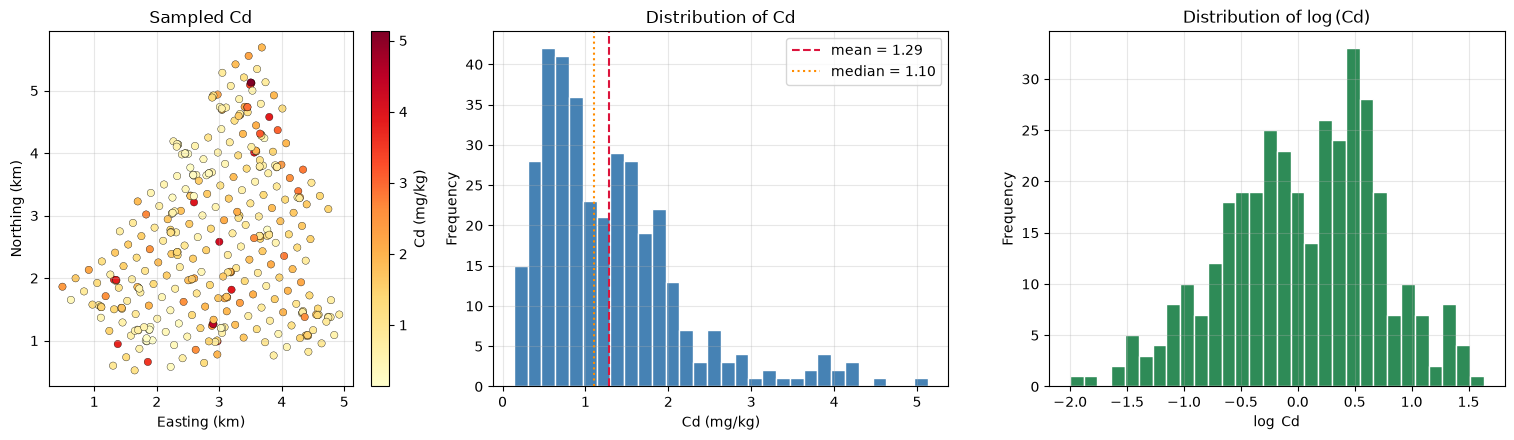

Grid extent: X [0.30, 5.10], Y [0.10, 5.90] km  (5957 nodes)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sc = axes[0].scatter(
    df[x_col], df[y_col], c=z, cmap="YlOrRd", s=28,
    edgecolors="k", linewidths=0.25,
)
plt.colorbar(sc, ax=axes[0], label=f"{target} (mg/kg)", fraction=0.046, pad=0.04)
axes[0].set_title(f"Sampled {target}")
axes[0].set_xlabel("Easting (km)")
axes[0].set_ylabel("Northing (km)")
axes[0].set_aspect("equal")

axes[1].hist(z, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(z.mean(), color="crimson", ls="--", label=f"mean = {z.mean():.2f}")
axes[1].axvline(np.median(z), color="darkorange", ls=":", label=f"median = {np.median(z):.2f}")
axes[1].set_title(f"Distribution of {target}")
axes[1].set_xlabel(f"{target} (mg/kg)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].hist(np.log(z), bins=30, color="seagreen", edgecolor="white")
axes[2].set_title(r"Distribution of $\log$(Cd)")
axes[2].set_xlabel(r"$\log$ Cd")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(
    f"Grid extent: X [{grid[x_col].min():.2f}, {grid[x_col].max():.2f}], "
    f"Y [{grid[y_col].min():.2f}, {grid[y_col].max():.2f}] km  ({len(grid)} nodes)"
)


***
## 5. Stratified Split and Log Transform

A purely random split can leave land-use class `4` (only 8 samples) under-represented in the test set. **Stratified random sampling** by `Landuse` keeps the class mix in both sets (`random_state=42`, same convention as Tutorials 02–05).

All subsequent fitting — the base variogram, the $K$ refits, ordinary kriging, and EBK — uses **training** $\log(\mathrm{Cd})$ only.


In [5]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(sss.split(df, df[strata_col]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

coords_train = df_train[[x_col, y_col]].values
coords_test = df_test[[x_col, y_col]].values
z_train = np.log(df_train[target].values.astype(float))
z_test = np.log(df_test[target].values.astype(float))
cd_train = df_train[target].values.astype(float)
cd_test = df_test[target].values.astype(float)

print(f"Train: {len(df_train)}    Test: {len(df_test)}")
print(f"log(Cd) train mean/std : {z_train.mean():.3f} / {z_train.std():.3f}")
print("Train Landuse counts:")
print(df_train[strata_col].value_counts().sort_index().to_string())
print("Test  Landuse counts:")
print(df_test[strata_col].value_counts().sort_index().to_string())


Train: 251    Test: 108
log(Cd) train mean/std : 0.060 / 0.656
Train Landuse counts:
Landuse
1     36
2     57
3    152
4      6
Test  Landuse counts:
Landuse
1    15
2    25
3    66
4     2


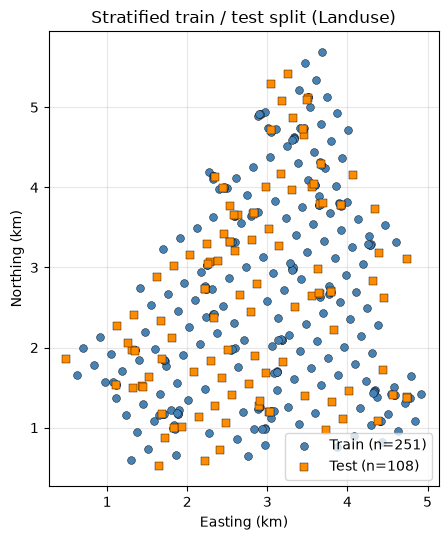

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(
    df_train[x_col], df_train[y_col], c="steelblue", s=32,
    edgecolors="k", linewidths=0.3, label=f"Train (n={len(df_train)})", zorder=3,
)
ax.scatter(
    df_test[x_col], df_test[y_col], c="darkorange", s=32, marker="s",
    edgecolors="k", linewidths=0.3, label=f"Test (n={len(df_test)})", zorder=3,
)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_title("Stratified train / test split (Landuse)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


***
## 6. Fit Empirical Bayesian Kriging

`EmpiricalBayesianKriging.fit` runs the simulate-refit-weight loop on the training locations, then fits one `OrdinaryKriging` per $\theta_k$ on the **real** $\log(\mathrm{Cd})$.

We use $K=40$ spherical members (`random_state=42`) — enough to see real spread in $\theta$, small enough that the notebook stays interactive. The library default is `n_realizations=100`.


In [7]:
K = 40

ebk = EmpiricalBayesianKriging(
    model="spherical",
    kriging_type="ordinary",
    n_realizations=K,
    use_gpu=False,
    random_state=42,
    variogram_kwargs={"n_lags": 15, "estimator": "matheron"},
)
ebk.fit(coords_train, z_train)

vg0 = ebk.base_variogram_
print("Empirical Bayesian Kriging fitted")
print(f"  n_realizations         : {ebk.n_realizations}")
print(f"  kriging_type           : {ebk.kriging_type}")
print(f"  base model             : {vg0.model}")
print(f"  base params [C0, C, a] : {np.round(vg0.fitted_params, 4)}")
print(f"  weights sum            : {ebk.weights_.sum():.6f}")
print(f"  weights min / max      : {ebk.weights_.min():.4f} / {ebk.weights_.max():.4f}")
print(f"  LOO RMSE min / mean / max : "
      f"{ebk.loo_rmse_.min():.3f} / {ebk.loo_rmse_.mean():.3f} / {ebk.loo_rmse_.max():.3f}")
print(f"  n krige models         : {len(ebk.krige_models_)}")


Empirical Bayesian Kriging fitted
  n_realizations         : 40
  kriging_type           : ordinary
  base model             : spherical
  base params [C0, C, a] : [0.2447 0.2102 1.3341]
  weights sum            : 1.000000
  weights min / max      : 0.0187 / 0.0304
  LOO RMSE min / mean / max : 0.508 / 0.562 / 0.647
  n krige models         : 40


***
## 7. The Semivariogram Ensemble

If the refits collapsed onto $\hat\theta_0$, there would be nothing for EBK to average over. `tests/test_ebk.py` requires the ensemble of ranges to have **nonzero spread**. Below: every $\gamma_k(h)$ overlaid on the base fit, the marginals of $(\mathrm{nugget},\,\mathrm{sill},\,\mathrm{range})$, and the LOO-MSE weights.


Ensemble parameter scatter (log-Cd spherical model)
  nugget  mean±sd : 0.245 ± 0.036   (base 0.245)
  sill    mean±sd : 0.237 ± 0.101   (base 0.210)
  range   mean±sd : 1.581 ± 0.975   (base 1.334)


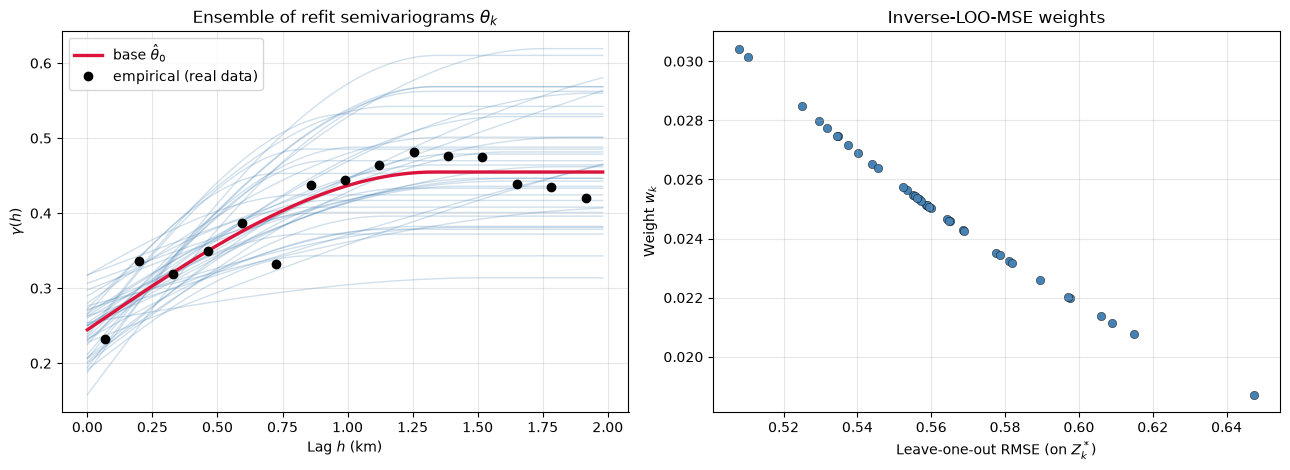

In [8]:
params = np.array([vg.fitted_params for vg in ebk.variograms_])  # (K, 3)
nugget, sill, rng_p = params[:, 0], params[:, 1], params[:, 2]

print("Ensemble parameter scatter (log-Cd spherical model)")
print(f"  nugget  mean±sd : {nugget.mean():.3f} ± {nugget.std():.3f}   (base {vg0.fitted_params[0]:.3f})")
print(f"  sill    mean±sd : {sill.mean():.3f} ± {sill.std():.3f}   (base {vg0.fitted_params[1]:.3f})")
print(f"  range   mean±sd : {rng_p.mean():.3f} ± {rng_p.std():.3f}   (base {vg0.fitted_params[2]:.3f})")
assert rng_p.std() > 0, "ensemble ranges should not collapse"

h_fine = np.linspace(0, vg0.maxlag, 250)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for vg, w in zip(ebk.variograms_, ebk.weights_):
    axes[0].plot(h_fine, vg(h_fine), color="steelblue", alpha=0.25, lw=1)
axes[0].plot(h_fine, vg0(h_fine), color="crimson", lw=2.4, label=r"base $\hat\theta_0$")
axes[0].plot(vg0.lags, vg0.experimental, "o", color="k", zorder=5, label="empirical (real data)")
axes[0].set_xlabel("Lag $h$ (km)")
axes[0].set_ylabel(r"$\gamma(h)$")
axes[0].set_title(r"Ensemble of refit semivariograms $\theta_k$")
axes[0].legend()

axes[1].scatter(ebk.loo_rmse_, ebk.weights_, c="steelblue", edgecolors="k", linewidths=0.3, s=36)
axes[1].set_xlabel("Leave-one-out RMSE (on $Z^*_k$)")
axes[1].set_ylabel(r"Weight $w_k$")
axes[1].set_title("Inverse-LOO-MSE weights")

plt.tight_layout()
plt.show()


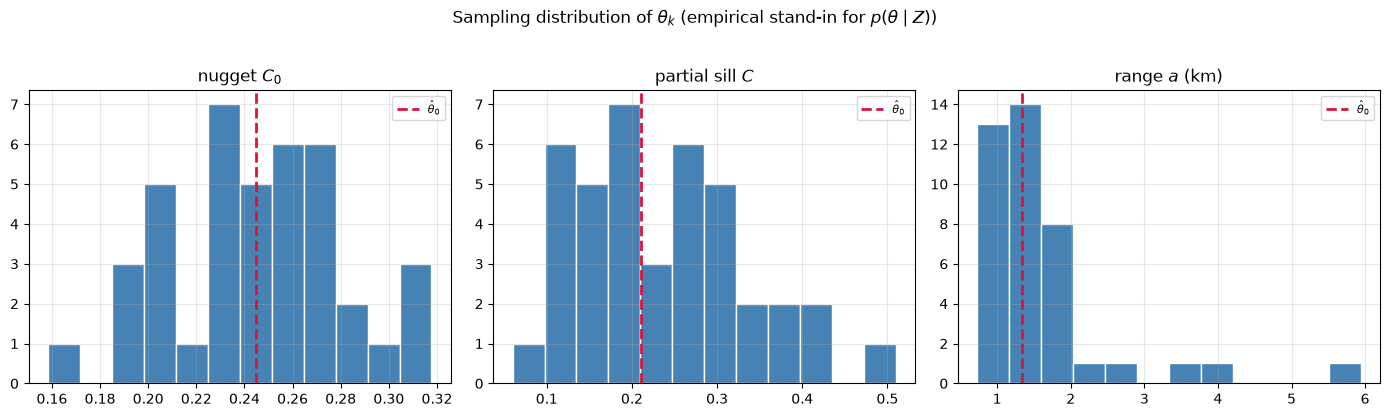

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
for ax, vals, name, base in zip(
    axes,
    [nugget, sill, rng_p],
    ["nugget $C_0$", "partial sill $C$", "range $a$ (km)"],
    vg0.fitted_params,
):
    ax.hist(vals, bins=12, color="steelblue", edgecolor="white")
    ax.axvline(base, color="crimson", ls="--", lw=2, label=r"$\hat\theta_0$")
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.suptitle(r"Sampling distribution of $\theta_k$ (empirical stand-in for $p(\theta\mid Z)$)", y=1.03)
plt.tight_layout()
plt.show()


***
## 8. Validate EBK vs Ordinary Kriging

Predict $\log(\mathrm{Cd})$ at the held-out 30%. Two claims from `tests/test_ebk.py`:

1. **Point estimates agree** with a single ordinary-kriging fit (correlation $\gtrsim 0.99$ on a dense grid in that test). EBK is not trying to beat OK on the mean.
2. **EBK's total SE exceeds OK's SE** almost everywhere: that extra margin *is* the between-model term plain kriging ignores.

We also decompose the EBK variance on the test set into within-model and between-model pieces, so the second term is visible as a number, not only as a larger SE.


In [10]:
vg_ok = Variogram(
    coords_train, z_train, model="spherical",
    estimator="matheron", n_lags=15, use_gpu=False,
)
vg_ok.fit()
ok = OrdinaryKriging(vg_ok, use_gpu=False).fit(coords_train, z_train)

z_hat_ebk, se_ebk_test = ebk.predict(coords_test, return_variance=True)
z_hat_ok, se_ok_test = ok.predict(coords_test, return_variance=True)

# Within / between decomposition (same combining rule as predict)
preds_k, var_k = ebk._predict_ensemble(coords_test, return_variance=True)
w = ebk.weights_[:, None]
within = (w * var_k).sum(axis=0)
between = (w * (preds_k - z_hat_ebk) ** 2).sum(axis=0)


def metrics(obs, pred, name):
    rmse = float(np.sqrt(mean_squared_error(obs, pred)))
    mae = float(mean_absolute_error(obs, pred))
    r2 = float(r2_score(obs, pred))
    me = float(np.mean(pred - obs))
    print(f"{name:22s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  ME={me:+.3f}")
    return rmse, mae, r2, me


print("Held-out test set (log Cd)")
metrics(z_test, z_hat_ebk, "Empirical Bayesian")
metrics(z_test, z_hat_ok, "Ordinary Kriging")
print(f"corr(EBK, OK) on test     : {np.corrcoef(z_hat_ebk, z_hat_ok)[0, 1]:.4f}")
print(f"EBK SE  min/mean/max      : {se_ebk_test.min():.3f} / {se_ebk_test.mean():.3f} / {se_ebk_test.max():.3f}")
print(f"OK  SE  min/mean/max      : {se_ok_test.min():.3f} / {se_ok_test.mean():.3f} / {se_ok_test.max():.3f}")
print(f"fraction SE_EBK >= SE_OK : {(se_ebk_test >= se_ok_test).mean():.3f}")
print(f"within-model var  (mean)  : {within.mean():.4f}")
print(f"between-model var (mean)  : {between.mean():.4f}")
print(f"between / total           : {between.mean() / (within.mean() + between.mean()):.3f}")


Held-out test set (log Cd)
Empirical Bayesian      RMSE=0.559  MAE=0.453  R2=0.381  ME=+0.015
Ordinary Kriging        RMSE=0.559  MAE=0.449  R2=0.383  ME=+0.011
corr(EBK, OK) on test     : 0.9982
EBK SE  min/mean/max      : 0.529 / 0.562 / 0.623
OK  SE  min/mean/max      : 0.530 / 0.559 / 0.621
fraction SE_EBK >= SE_OK : 0.769
within-model var  (mean)  : 0.3132
between-model var (mean)  : 0.0032
between / total           : 0.010


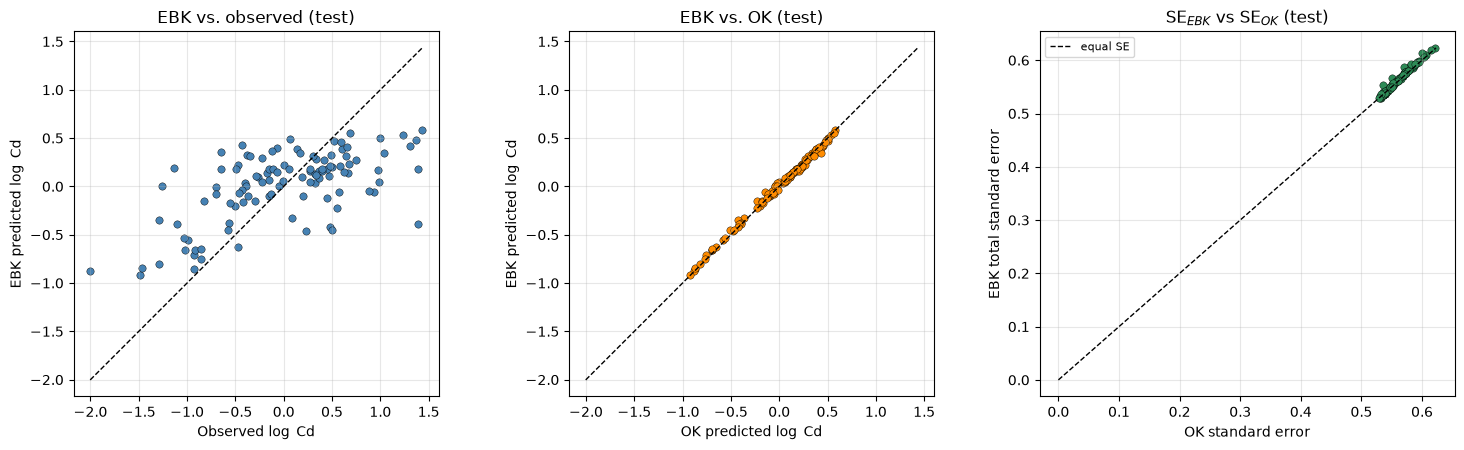

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

lo = min(z_test.min(), z_hat_ebk.min(), z_hat_ok.min())
hi = max(z_test.max(), z_hat_ebk.max(), z_hat_ok.max())

axes[0].scatter(z_test, z_hat_ebk, c="steelblue", edgecolors="k", linewidths=0.3, s=28)
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_xlabel(r"Observed $\log$ Cd")
axes[0].set_ylabel(r"EBK predicted $\log$ Cd")
axes[0].set_title("EBK vs. observed (test)")
axes[0].set_aspect("equal", adjustable="box")

axes[1].scatter(z_hat_ok, z_hat_ebk, c="darkorange", edgecolors="k", linewidths=0.3, s=28)
axes[1].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[1].set_xlabel(r"OK predicted $\log$ Cd")
axes[1].set_ylabel(r"EBK predicted $\log$ Cd")
axes[1].set_title("EBK vs. OK (test)")
axes[1].set_aspect("equal", adjustable="box")

axes[2].scatter(se_ok_test, se_ebk_test, c="seagreen", edgecolors="k", linewidths=0.3, s=28)
m = max(se_ok_test.max(), se_ebk_test.max())
axes[2].plot([0, m], [0, m], "k--", lw=1, label="equal SE")
axes[2].set_xlabel("OK standard error")
axes[2].set_ylabel("EBK total standard error")
axes[2].set_title(r"SE$_{EBK}$ vs SE$_{OK}$ (test)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


***
## 9. Predict Cd on the Jura Grid

Apply the fitted EBK and OK models to every node in `jura_grid.csv`. Maps are shown in $\log(\mathrm{Cd})$ (the modelling scale) and as $\exp(\hat Z)$ for a Cd-unit reading. $\exp(\hat Z)$ is a median-type back-transform of the log-Gaussian predictor, not an unbiased mean of Cd.


In [12]:
preds_g, var_g = ebk._predict_ensemble(grid_coords, return_variance=True)
w = ebk.weights_[:, None]
pred_ebk = (w * preds_g).sum(axis=0)
within_g = (w * var_g).sum(axis=0)
between_g = (w * (preds_g - pred_ebk) ** 2).sum(axis=0)
se_ebk = np.sqrt(np.clip(within_g + between_g, 0, None))
pred_ok, se_ok = ok.predict(grid_coords, return_variance=True)

grid_out = grid.copy()
grid_out["logCd_ebk"] = pred_ebk
grid_out["logCd_ebk_se"] = se_ebk
grid_out["logCd_ok"] = pred_ok
grid_out["logCd_ok_se"] = se_ok
grid_out["Cd_ebk"] = np.exp(pred_ebk)
grid_out["Cd_ok"] = np.exp(pred_ok)

print(f"Grid predictions: n = {len(pred_ebk)}")
print(
    f"  EBK log-Cd  min/mean/max : {pred_ebk.min():.3f} / {pred_ebk.mean():.3f} / {pred_ebk.max():.3f}"
)
print(
    f"  EBK SE      min/mean/max : {se_ebk.min():.3f} / {se_ebk.mean():.3f} / {se_ebk.max():.3f}"
)
print(
    f"  OK  SE      min/mean/max : {se_ok.min():.3f} / {se_ok.mean():.3f} / {se_ok.max():.3f}"
)
print(f"  corr(EBK, OK) on grid    : {np.corrcoef(pred_ebk, pred_ok)[0, 1]:.4f}")
print(f"  fraction SE_EBK >= SE_OK: {(se_ebk >= se_ok).mean():.3f}")
print(f"  mean within / between   : {within_g.mean():.4f} / {between_g.mean():.4f}")
assert np.isfinite(pred_ebk).all() and np.isfinite(se_ebk).all()
assert np.all(se_ebk >= 0)
grid_out[[x_col, y_col, "logCd_ebk", "logCd_ebk_se", "Cd_ebk"]].head()


Grid predictions: n = 5957
  EBK log-Cd  min/mean/max : -0.955 / 0.088 / 0.627
  EBK SE      min/mean/max : 0.527 / 0.571 / 0.679
  OK  SE      min/mean/max : 0.529 / 0.569 / 0.675
  corr(EBK, OK) on grid    : 0.9976
  fraction SE_EBK >= SE_OK: 0.868
  mean within / between   : 0.3241 / 0.0030


,Xloc,Yloc,logCd_ebk,logCd_ebk_se,Cd_ebk
0,0.30,1.70,-0.137567,0.647850,0.871476
1,0.35,1.70,-0.148991,0.640317,0.861577
2,0.35,1.75,-0.127347,0.638360,0.880428
3,0.40,1.70,-0.159987,0.632041,0.852155
4,0.40,1.75,-0.134929,0.629932,0.873778


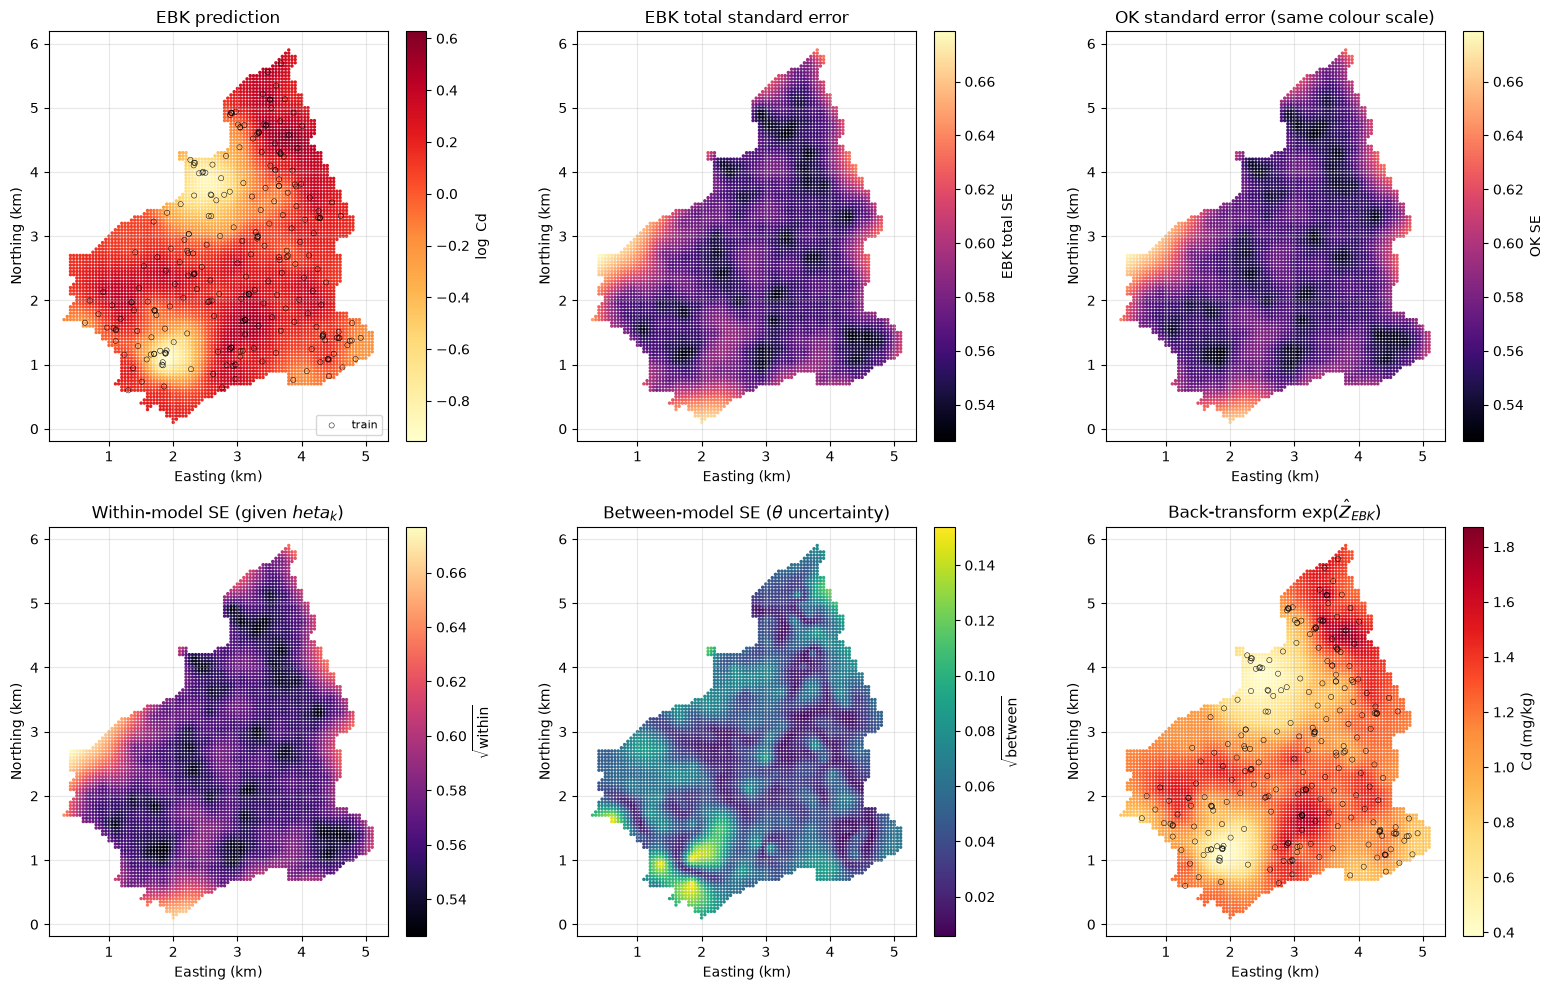

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sc0 = axes[0, 0].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["logCd_ebk"],
    cmap="YlOrRd", s=8, marker=".",
)
axes[0, 0].scatter(
    df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
    s=14, linewidths=0.35, label="train",
)
plt.colorbar(sc0, ax=axes[0, 0], label=r"$\log$ Cd", fraction=0.046, pad=0.04)
axes[0, 0].set_aspect("equal")
axes[0, 0].set_title("EBK prediction")
axes[0, 0].set_xlabel("Easting (km)")
axes[0, 0].set_ylabel("Northing (km)")
axes[0, 0].legend(loc="lower right", fontsize=8)

sc1 = axes[0, 1].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["logCd_ebk_se"],
    cmap="magma", s=8, marker=".",
)
plt.colorbar(sc1, ax=axes[0, 1], label="EBK total SE", fraction=0.046, pad=0.04)
axes[0, 1].set_aspect("equal")
axes[0, 1].set_title("EBK total standard error")
axes[0, 1].set_xlabel("Easting (km)")
axes[0, 1].set_ylabel("Northing (km)")

sc2 = axes[0, 2].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["logCd_ok_se"],
    cmap="magma", s=8, marker=".",
    vmin=grid_out["logCd_ebk_se"].min(), vmax=grid_out["logCd_ebk_se"].max(),
)
plt.colorbar(sc2, ax=axes[0, 2], label="OK SE", fraction=0.046, pad=0.04)
axes[0, 2].set_aspect("equal")
axes[0, 2].set_title("OK standard error (same colour scale)")
axes[0, 2].set_xlabel("Easting (km)")
axes[0, 2].set_ylabel("Northing (km)")

sc3 = axes[1, 0].scatter(
    grid_out[x_col], grid_out[y_col], c=np.sqrt(within_g),
    cmap="magma", s=8, marker=".",
)
plt.colorbar(sc3, ax=axes[1, 0], label=r"$\sqrt{\mathrm{within}}$", fraction=0.046, pad=0.04)
axes[1, 0].set_aspect("equal")
axes[1, 0].set_title("Within-model SE (given $\theta_k$)")
axes[1, 0].set_xlabel("Easting (km)")
axes[1, 0].set_ylabel("Northing (km)")

sc4 = axes[1, 1].scatter(
    grid_out[x_col], grid_out[y_col], c=np.sqrt(between_g),
    cmap="viridis", s=8, marker=".",
)
plt.colorbar(sc4, ax=axes[1, 1], label=r"$\sqrt{\mathrm{between}}$", fraction=0.046, pad=0.04)
axes[1, 1].set_aspect("equal")
axes[1, 1].set_title(r"Between-model SE ($\theta$ uncertainty)")
axes[1, 1].set_xlabel("Easting (km)")
axes[1, 1].set_ylabel("Northing (km)")

sc5 = axes[1, 2].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["Cd_ebk"],
    cmap="YlOrRd", s=8, marker=".",
)
axes[1, 2].scatter(
    df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
    s=14, linewidths=0.35,
)
plt.colorbar(sc5, ax=axes[1, 2], label="Cd (mg/kg)", fraction=0.046, pad=0.04)
axes[1, 2].set_aspect("equal")
axes[1, 2].set_title(r"Back-transform $\exp(\hat Z_{EBK})$")
axes[1, 2].set_xlabel("Easting (km)")
axes[1, 2].set_ylabel("Northing (km)")

plt.tight_layout()
plt.show()


***
## 10. Probability Maps of Exceedance

`predict_proba` mixes the $K$ Gaussians $N(\hat Z_k,\sigma_k^2)$ with weights $w_k$. That is **not** the same as plugging $(\hat Z_{\mathrm{EBK}},\sigma_{\mathrm{EBK}})$ into a single $\Phi$ — the mixture keeps the extra spread from $\theta$-uncertainty instead of smoothing it into one Gaussian.

Because the model is on $\log(\mathrm{Cd})$, $P(\mathrm{Cd} > z_c) = P(\log\mathrm{Cd} > \log z_c)$. We map $z_c \in \{0.50, 1.00, 1.50, 2.00\}$ mg/kg. Mean exceedance probability across the grid must decrease as the cutoff rises (`test_predict_proba_decreases_with_cutoff_on_average`).


In [14]:
cutoffs_cd = [0.50, 1.00, 1.50, 2.00]  # mg/kg
cutoffs_log = [float(np.log(zc)) for zc in cutoffs_cd]
probs = ebk.predict_proba(grid_coords, cutoffs_log)

prob_cols = []
for zc, zc_log in zip(cutoffs_cd, cutoffs_log):
    col = f"P_Cd_gt_{zc:.2f}".replace(".", "p")
    grid_out[col] = probs[zc_log]
    prob_cols.append(col)
    p = probs[zc_log]
    assert p.shape == (len(grid_coords),)
    assert np.all((p >= 0) & (p <= 1))
    print(
        f"P(Cd > {zc:4.2f})  mean={p.mean():.3f}  min={p.min():.3f}  max={p.max():.3f}"
    )

print()
print("Monotone in the mean?",
      all(probs[cutoffs_log[i]].mean() > probs[cutoffs_log[i + 1]].mean()
          for i in range(len(cutoffs_log) - 1)))

emp = {zc: float(np.mean(cd_train > zc)) for zc in cutoffs_cd}
print("Empirical P(Cd > zc) on training samples:")
for zc, p in emp.items():
    print(f"  {zc:4.2f} mg/kg : {p:.3f}")


P(Cd > 0.50)  mean=0.887  min=0.315  max=0.990
P(Cd > 1.00)  mean=0.563  min=0.043  max=0.870
P(Cd > 1.50)  mean=0.314  min=0.008  max=0.656
P(Cd > 2.00)  mean=0.171  min=0.002  max=0.454

Monotone in the mean? True
Empirical P(Cd > zc) on training samples:
  0.50 mg/kg : 0.873
  1.00 mg/kg : 0.546
  1.50 mg/kg : 0.351
  2.00 mg/kg : 0.155


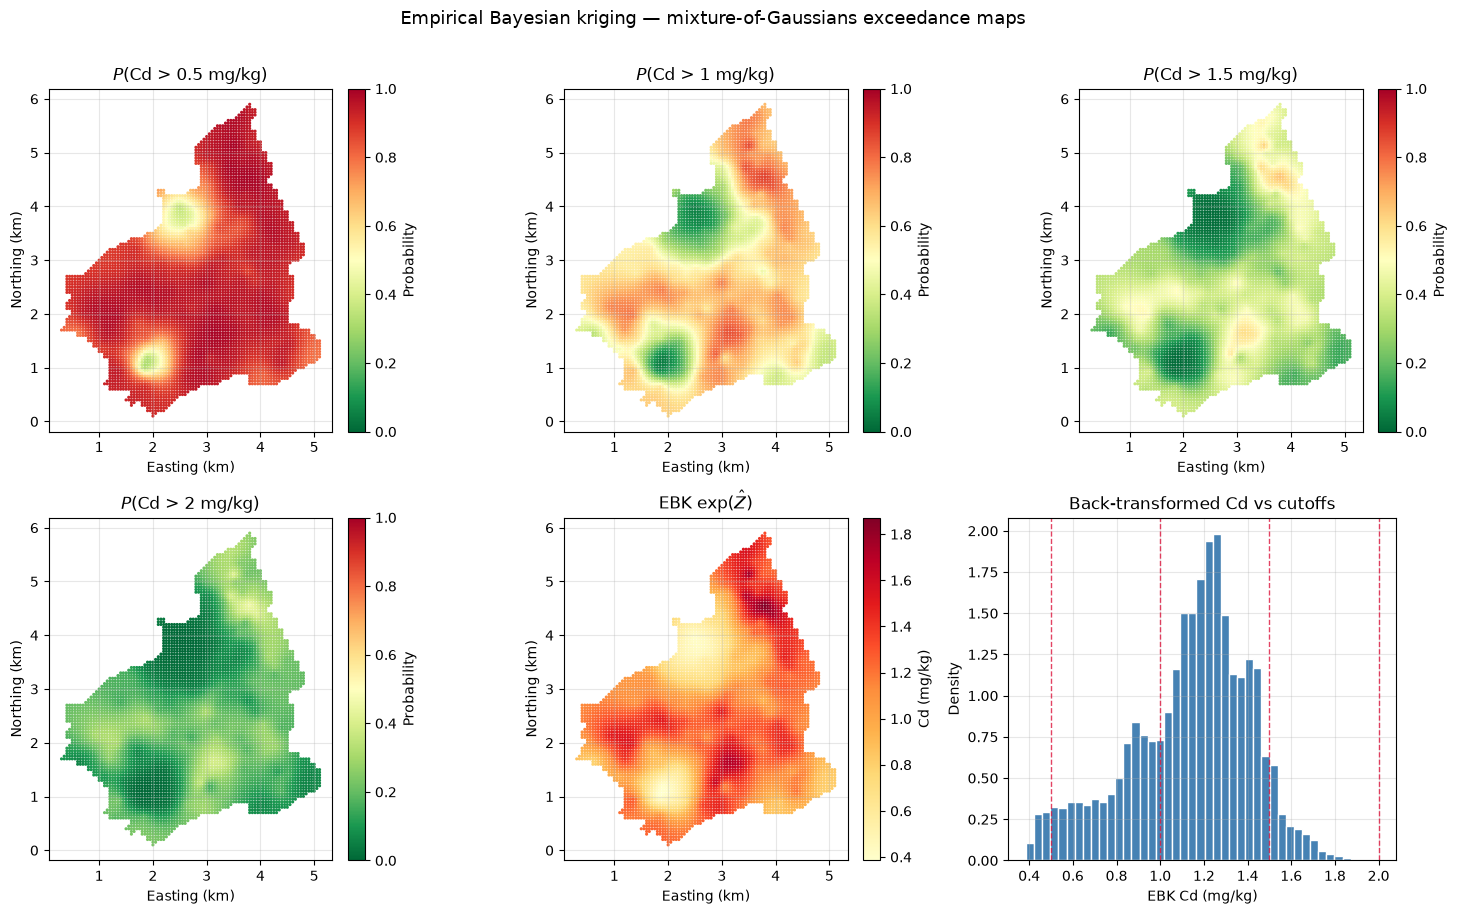

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, zc, col in zip(axes, cutoffs_cd, prob_cols):
    sc = ax.scatter(
        grid_out[x_col], grid_out[y_col], c=grid_out[col],
        cmap="RdYlGn_r", s=6, marker=".", vmin=0, vmax=1,
    )
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Probability")
    ax.set_aspect("equal")
    ax.set_title(f"$P$(Cd > {zc:g} mg/kg)")
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")

sc = axes[4].scatter(
    grid_out[x_col], grid_out[y_col], c=grid_out["Cd_ebk"],
    cmap="YlOrRd", s=6, marker=".",
)
plt.colorbar(sc, ax=axes[4], fraction=0.046, pad=0.04, label="Cd (mg/kg)")
axes[4].set_aspect("equal")
axes[4].set_title(r"EBK $\exp(\hat Z)$")
axes[4].set_xlabel("Easting (km)")
axes[4].set_ylabel("Northing (km)")

axes[5].hist(grid_out["Cd_ebk"], bins=40, color="steelblue", edgecolor="white", density=True)
for zc in cutoffs_cd:
    axes[5].axvline(zc, color="crimson", ls="--", lw=1, alpha=0.8)
axes[5].set_title("Back-transformed Cd vs cutoffs")
axes[5].set_xlabel("EBK Cd (mg/kg)")
axes[5].set_ylabel("Density")

plt.suptitle("Empirical Bayesian kriging — mixture-of-Gaussians exceedance maps", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [16]:
# Test-set Brier scores of the EBK mixture vs a single-Gaussian OK probability
probs_test = ebk.predict_proba(coords_test, cutoffs_log)
se_ok_safe = np.clip(se_ok_test, 1e-8, None)
rows = []
for zc, zc_log in zip(cutoffs_cd, cutoffs_log):
    ind = (cd_test > zc).astype(float)
    p_ebk = probs_test[zc_log]
    p_ok = 1.0 - norm.cdf((zc_log - z_hat_ok) / se_ok_safe)
    brier_ebk = float(np.mean((p_ebk - ind) ** 2))
    brier_ok = float(np.mean((p_ok - ind) ** 2))
    base = float(ind.mean())
    brier_base = float(base * (1.0 - base))
    rows.append({
        "cutoff": zc,
        "Brier_EBK": brier_ebk,
        "Brier_OK": brier_ok,
        "Brier_noskill": brier_base,
        "skill_EBK": 1.0 - brier_ebk / brier_base if brier_base > 0 else np.nan,
        "mean_p_EBK": float(p_ebk.mean()),
        "empirical": float(ind.mean()),
    })
brier_tbl = pd.DataFrame(rows).round(3)
print("Test-set Brier scores (lower is better; skill > 0 beats the marginal frequency)")
brier_tbl


Test-set Brier scores (lower is better; skill > 0 beats the marginal frequency)


,cutoff,Brier_EBK,Brier_OK,Brier_noskill,skill_EBK,mean_p_EBK,empirical
0,0.5,0.084,0.081,0.145,0.421,0.852,0.824
1,1.0,0.203,0.203,0.250,0.187,0.517,0.509
2,1.5,0.189,0.190,0.216,0.125,0.282,0.315
3,2.0,0.098,0.100,0.106,0.070,0.152,0.120


***
## 11. Summary and Conclusions

- **Empirical Bayesian kriging** does not commit to a single semivariogram $\hat\theta$. It builds an empirical distribution over plausible $\theta$ by simulating Gaussian realizations from a base fit, refitting, and weighting, then kriges the real data with every member of that ensemble.
- **`pygstat.EmpiricalBayesianKriging`** implements the global (single-window) form of that recipe. Each member is ordinary (or simple) kriging; `predict()` combines them with the law-of-total-variance / Rubin rule; `predict_proba` mixes the $K$ predictive Gaussians rather than collapsing them to one.
- On **Jura cadmium** ($\log$ scale, $K=40$), the ensemble of spherical models showed real spread in nugget, sill, and range. Inverse-LOO-MSE weights downweighted the worst refits.
- **Held-out point estimates** tracked ordinary kriging closely. **EBK standard errors were larger than OK's** on the test set and on the grid — that extra width is the between-model term, the $\theta$-uncertainty plain kriging ignores.
- **Exceedance maps** $P(\mathrm{Cd}>z_c)$ come from the mixture. Mean probability decreased with the cutoff, and test-set Brier scores beat the no-skill baseline.

| Object | Role in this notebook |
|---|---|
| `base_variogram_` | $\hat\theta_0$; simulation only |
| `variograms_` | Refit ensemble $\{\theta_k\}$ |
| `weights_` | Inverse-LOO-MSE precision weights |
| `predict` | $\hat Z_{\mathrm{EBK}}$ and total SE |
| `predict_proba` | Mixture-of-Gaussians $P(Z>z_c)$ |

### Practical takeaways

- Use EBK when you care about **honest prediction variance** or **calibrated probabilities**, especially with a modest sample or an ill-determined range/nugget.
- EBK is still a **linear** interpolator of the (transformed) data. For a richer *point estimate* of a skewed grade, use disjunctive kriging (Tutorial 10) — the two ideas address different OK failures and can in principle be combined.
- Transform skewed variables before the simulate-and-refit loop. This class does not auto-transform, and it does not yet run local moving windows.
- $K=100$ is the library/ArcGIS default. Smaller $K$ is fine for exploration; check that the ensemble of ranges has not collapsed.

### Next steps

- Compare these $P(\mathrm{Cd}>1)$ maps with Tutorial 07 (indicator kriging) and Tutorial 10 (disjunctive kriging) on the same survey
- Sequential Gaussian simulation (Tutorial 18) draws *realizations of the field* given one $\theta$; EBK averages *kriging predictors* over an ensemble of $\theta$


***
## 12. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Diggle, P.J. & Ribeiro, P.J. (2007). *Model-based Geostatistics*. Springer. | Fully Bayesian geostatistics; the MCMC target EBK approximates |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | Variogram-parameter uncertainty; model averaging |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Jura Cd case study |
| Banerjee, S., Carlin, B.P. & Gelfand, A.E. (2014). *Hierarchical Modeling and Analysis for Spatial Data* (2nd ed.). CRC. | Hierarchical (fully Bayesian) spatial models |

### Key papers

| Paper | Contribution |
|---|---|
| Krivoruchko, K. (2012). Empirical Bayesian Kriging. *ArcUser* Fall 2012, 6–10. | EBK as implemented in ArcGIS Geostatistical Analyst |
| Krivoruchko, K. & Gribov, A. (2019). Evaluation of empirical Bayesian kriging. *Spatial Statistics* 32, 100368. | Formal evaluation of EBK vs classical kriging |
| Handcock, M.S. & Stein, M.L. (1993). A Bayesian analysis of kriging. *Technometrics* 35, 403–410. | Fully Bayesian kriging with a prior on $\theta$ |
| Rubin, D.B. (1987). *Multiple Imputation for Nonresponse in Surveys*. Wiley. | Within + between combining rule reused by EBK |

### In this library

| Object | Role |
|---|---|
| `pygstat.EmpiricalBayesianKriging` | Simulate-refit-weight ensemble; `predict` / `predict_proba` |
| `pygstat.OrdinaryKriging` / `SimpleKriging` | Per-member kriging engine |
| `pygstat.Variogram` | Base fit and every refit |
| `pygstat.loo_cv` | Leave-one-out weights |
| `tests/test_ebk.py` | Synthetic API, Meuse SE-inflation claim, GPU smoke tests |
